In [388]:
import pandas as pd
import numpy as np  
from datetime import datetime, date
import matplotlib.pyplot as plt
import seaborn

from plotting import plot_mutual_info_heatmap
from plotting import mutual_info_regression_matrix


In [ ]:
lb_df = pd.read_csv("/Users/heerperchani/Desktop/AI4Good/furcast/datasets/animal-shelter-intakes-and-outcomes.csv")
# lb_df[lb_df.duplicated(subset="Animal ID",keep=False)]

,Kennel ID,Animal ID,Animal Name,Animal Type,Primary Color,Secondary Color,Sex,DOB,Intake Date,Intake Condition,...,longitude,intake_is_dead,geopoint,intake_duration,is_current_month,outcome_is_dead,outcome_is_current,outcome_is_other,outcome_is_alive,was_outcome_alive
1,285586,A591341,NaN,CAT,CALICO,NaN,Unknown,2017-05-20,2017-06-04,UNDER AGE/WEIGHT,...,-118.107586,Alive on Intake,"33.816764, -118.1075857",1.0,False,False,False,False,True,1
11,308041,A606500,*BANANNA BLUE,CAT,BLACK,WHITE,Neutered,2012-11-16,2019-08-26,NORMAL,...,-118.196484,Alive on Intake,"33.81766650000001, -118.196484",0.0,False,False,False,False,True,1
22,320793,A648582,*GAMORA,CAT,GRAY TABBY,WHITE,Spayed,2020-07-10,2020-11-25,BEHAVIOR MILD,...,-118.280657,Alive on Intake,"34.0660343, -118.2806572",3.0,False,False,False,False,True,1
27,351780,A708759,*VALLORIA,DOG,BLACK,BROWN,Spayed,2023-04-13,2023-10-13,I/I REPORT,...,-118.152360,Alive on Intake,"33.8762965, -118.1523595",23.0,False,False,False,False,True,1
48,343078,A696087,NINA,DOG,BLACK,WHITE,Female,2022-11-10,2023-04-04,INJURED MODERATE,...,-118.155648,Alive on Intake,"33.873364, -118.1556482",5.0,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55172,384890,A746481,*CHAMPION,DOG,WHITE,BROWN,Neutered,2023-08-02,2025-08-15,NORMAL,...,-118.128498,Alive on Intake,"33.7973401, -118.1284976",36.0,False,False,False,False,True,1
55194,334391,A556069,SNOW,CAT,FLAME PT,NaN,Neutered,2014-06-01,2022-06-04,NORMAL,...,-118.179095,Alive on Intake,"33.8543545, -118.1790948",48.0,False,False,False,False,True,1
55296,354881,A710503,*RIGGS,DOG,WHITE,GRAY,Neutered,2020-11-14,2024-02-10,NORMAL,...,-118.110738,Alive on Intake,"33.8566606, -118.1107378",71.0,False,False,False,False,True,1
55324,336480,A678401,*MELROSE,DOG,YELLOW,NaN,Spayed,2021-06-26,2022-07-15,NORMAL,...,-118.036877,Alive on Intake,"33.8558316, -118.0368767",1.0,False,False,False,False,True,1


In [ ]:
#removing the columns we will not be using 
lb_df_cleaned = lb_df.drop(["Kennel ID","latitude","longitude","Animal Name","Secondary Color","Intake Subtype","Reason for Intake","Crossing","Jurisdiction","Outcome Subtype","outcome_is_dead","was_outcome_alive","geopoint","is_current_month", "intake_duration","outcome_is_current","outcome_is_other","outcome_is_alive","intake_is_dead"], axis=1)


In [376]:
age_days = pd.to_datetime(lb_df_cleaned["Intake Date"]) - pd.to_datetime(lb_df_cleaned["DOB"])
age_days.head()

lb_df_cleaned["age_in_years"] = (age_days /pd.to_timedelta(365.4525, "D")).round(2)

#age added in years 



In [377]:
days_spent = pd.to_datetime(lb_df_cleaned["Outcome Date"]) - pd.to_datetime(lb_df_cleaned["Intake Date"])
lb_df_cleaned["duration_in_days"] = days_spent/pd.to_timedelta(1,"D") #this is float num of days
#numbers of days spent in shelter added



In [ ]:
#tried looking for duplicates but no rows were dropped 
lb_df_cleaned.drop_duplicates()
lb_df_cleaned[lb_df_cleaned["age_in_years"].isna()]

#there are 6968 rows with no DOB so no age 


,Animal ID,Animal Type,Primary Color,Sex,DOB,Intake Date,Intake Condition,Intake Type,Outcome Date,Outcome Type,age_in_years,duration_in_days
4,A598491,WILD,GRAY,Unknown,NaN,2017-10-09,INJURED SEVERE,WILDLIFE,2017-10-09,TRANSFER,NaN,0.0
32,A756063,CAT,GRAY TABBY,Neutered,NaN,2026-02-07,INJURED MILD,STRAY,2026-02-23,COMMUNITY CAT,NaN,16.0
41,A721269,CAT,ORANGE,Male,NaN,2024-05-21,ILL MILD,STRAY,2024-05-23,EUTHANASIA,NaN,2.0
61,A644651,BIRD,BROWN,Unknown,NaN,2020-07-01,INJURED MILD,WILDLIFE,2020-07-01,EUTHANASIA,NaN,0.0
63,A644112,OTHER,GRAY,Female,NaN,2020-06-20,INJURED SEVERE,WILDLIFE,2020-06-20,RETURN TO WILD HABITAT,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
55282,A611520,GUINEA PIG,TRICOLOR,Unknown,NaN,2018-07-23,NORMAL,CONFISCATE,2018-08-04,ADOPTION,NaN,12.0
55293,A648274,CAT,BLACK,Male,NaN,2020-09-04,INJURED MODERATE,STRAY,2020-09-11,TRANSFER,NaN,7.0
55303,A740863,CAT,BLACK,Male,NaN,2025-05-17,UNDER AGE/WEIGHT,STRAY,2025-05-24,DIED,NaN,7.0
55309,A667743,BIRD,BROWN,Unknown,NaN,2021-12-07,INJURED MODERATE,WILDLIFE,2021-12-07,TRANSFER,NaN,0.0


array([[<Axes: title={'center': 'Intake Date'}>]], dtype=object)

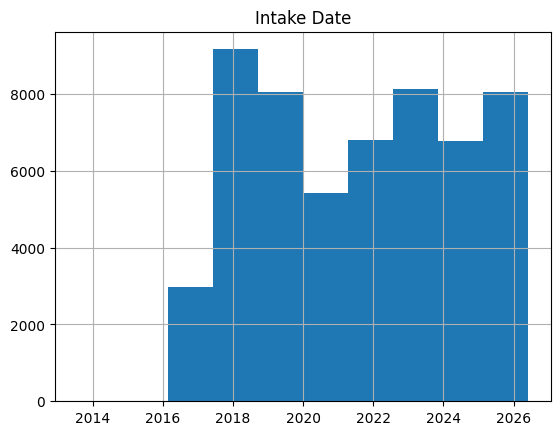

In [ ]:
lb_df_cleaned[lb_df_cleaned["duration_days"] <= 70]["duration"].hist(bins=50)
plt.xlabel("Time in Shelter (days)")
plt.ylabel("Number of Animals")
plt.title("Distribution of Time in Shelter")
plt.show()

array([[<Axes: title={'center': 'Outcome Date'}>]], dtype=object)

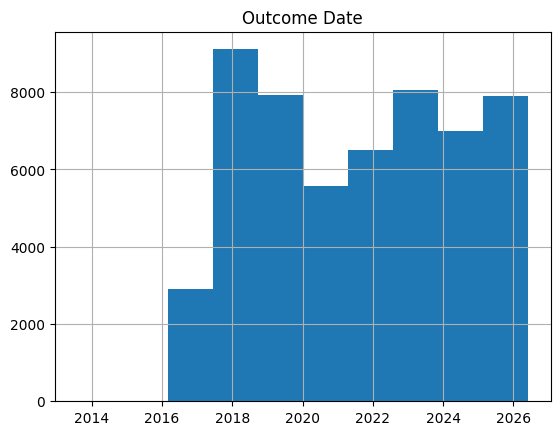

In [325]:
lb_df_cleaned.hist(column="Outcome Date")

<Axes: >

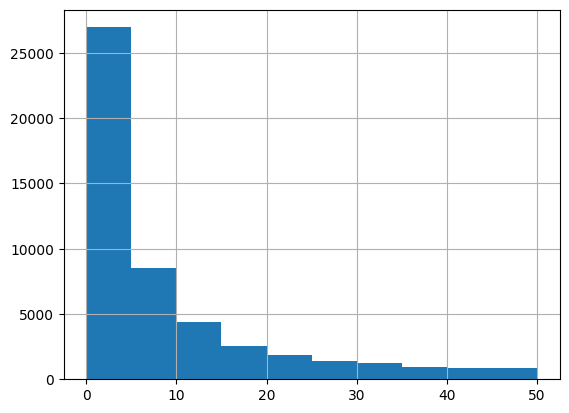

In [370]:
filtered_df = lb_df_cleaned[(lb_df_cleaned['Duration'] <= 50)]["Duration"]
filtered_df.hist()

<Axes: xlabel='Animal Type'>

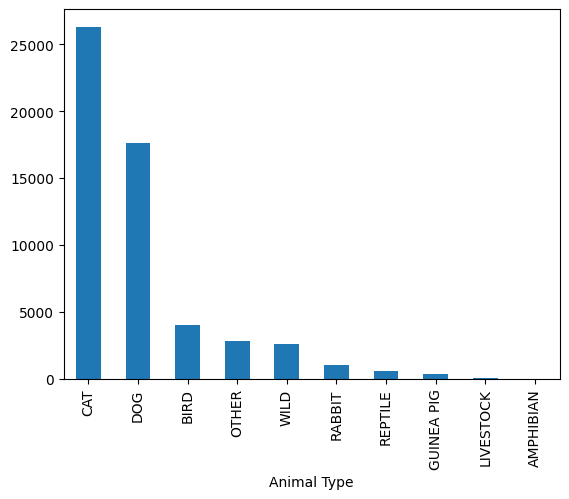

In [345]:
lb_df_cleaned["Animal Type"].value_counts().plot(kind = "bar")


<Axes: xlabel='Intake Condition'>

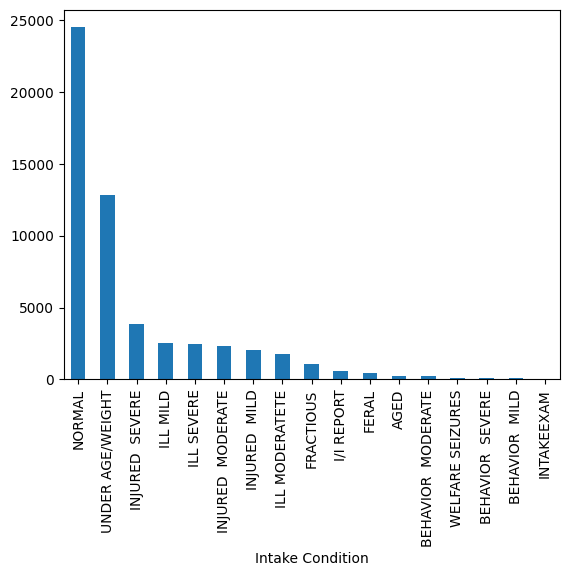

In [346]:
lb_df_cleaned["Intake Condition"].value_counts().plot(kind = "bar")

<Axes: xlabel='Intake Type'>

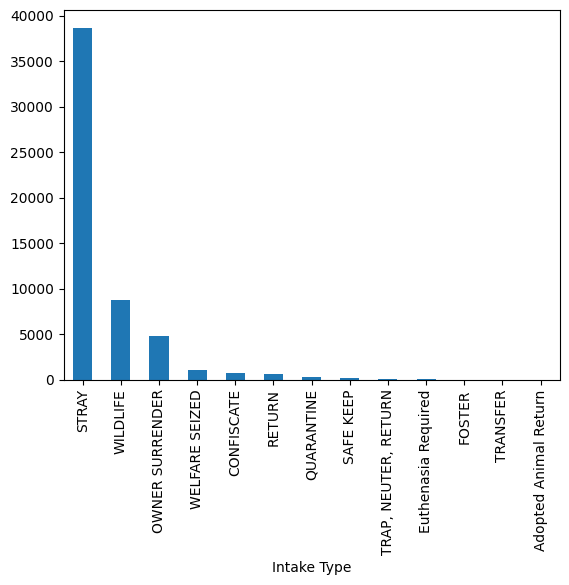

In [347]:
lb_df_cleaned["Intake Type"].value_counts().plot(kind = "bar")

In [424]:
lb_df_cleaned["Outcome Type"].value_counts()

Outcome Type
RESCUE                     13148
ADOPTION                   11924
EUTHANASIA                 10304
TRANSFER                    7851
RETURN TO OWNER             5630
SHELTER, NEUTER, RETURN     1395
DIED                        1341
COMMUNITY CAT               1057
TRANSPORT                    753
RETURN TO WILD HABITAT       533
FOSTER TO ADOPT              342
DISPOSAL                     146
HOMEFIRST                    143
MISSING                      127
TRAP, NEUTER, RELEASE         98
RETURN TO RESCUE              71
DUPLICATE                     65
FOSTER                        17
Name: count, dtype: int64

In [ ]:
lb_df_cleaned["Primary Color"].value_counts()

Primary Color
BLACK         14025
GRAY           7374
WHITE          6687
BROWN          6586
BRN TABBY      4204
              ...  
LIVER TICK        1
RED TICK          1
CT LYNX PT        1
CH LYNX PT        1
ST LYNX PT        1
Name: count, Length: 86, dtype: int64

<Axes: xlabel='Sex'>

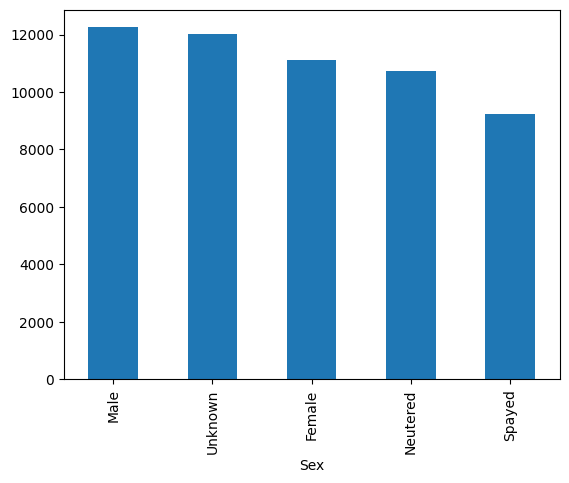

In [349]:
lb_df_cleaned["Sex"].value_counts().plot(kind="bar")

In [413]:
lb_df_cleaned["Intake Type"].value_counts()

Intake Type
STRAY                    38713
WILDLIFE                  8777
OWNER SURRENDER           4828
WELFARE SEIZED            1086
CONFISCATE                 679
RETURN                     633
QUARANTINE                 289
SAFE KEEP                  185
TRAP, NEUTER, RETURN       119
Euthenasia Required         21
FOSTER                       7
TRANSFER                     4
Adopted Animal Return        3
Name: count, dtype: int64

In [420]:
lb_df_cleaned["Outcome Type"].value_counts()


# rescue,trasnfer is trasnfer 
# adoption is adoption
# euthanasia is euthanasia 
# return to owner is owner surrender 
# foster to adopt, foster is foster
# everything else is other 


Outcome Type
RESCUE                     13148
ADOPTION                   11924
EUTHANASIA                 10304
TRANSFER                    7851
RETURN TO OWNER             5630
SHELTER, NEUTER, RETURN     1395
DIED                        1341
COMMUNITY CAT               1057
TRANSPORT                    753
RETURN TO WILD HABITAT       533
FOSTER TO ADOPT              342
DISPOSAL                     146
HOMEFIRST                    143
MISSING                      127
TRAP, NEUTER, RELEASE         98
RETURN TO RESCUE              71
DUPLICATE                     65
FOSTER                        17
Name: count, dtype: int64

,Animal ID,Animal Type,Primary Color,Sex,DOB,Intake Date,Intake Condition,Intake Type,Outcome Date,Outcome Type,age_in_years,duration_in_days
65,A696081,DOG,GRAY,Neutered,2016-04-03,2023-04-03,I/I REPORT,STRAY,2023-08-16,ADOPTION,6.99,135.0
604,A718053,CAT,BLACK,Neutered,2024-03-02,2024-04-04,UNDER AGE/WEIGHT,STRAY,2024-06-22,ADOPTION,0.09,79.0
605,A718053,CAT,BLACK,Neutered,2024-03-02,2024-04-04,UNDER AGE/WEIGHT,STRAY,2024-06-22,ADOPTION,0.09,79.0
1571,A758494,CAT,BLACK,Female,2026-03-15,2026-03-23,UNDER AGE/WEIGHT,STRAY,2026-03-23,RESCUE,0.02,0.0
1572,A758494,CAT,BLACK,Female,2026-03-15,2026-03-23,UNDER AGE/WEIGHT,STRAY,2026-03-23,RESCUE,0.02,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
52022,A741066,CAT,GRAY TABBY,Female,2023-05-21,2025-05-21,NORMAL,STRAY,2025-06-04,COMMUNITY CAT,2.00,14.0
52120,A696081,DOG,GRAY,Neutered,2016-04-03,2023-04-03,I/I REPORT,STRAY,2023-08-16,ADOPTION,6.99,135.0
53662,A758494,CAT,BLACK,Female,2026-03-15,2026-03-23,UNDER AGE/WEIGHT,STRAY,2026-03-23,RESCUE,0.02,0.0
53664,A758493,CAT,GRAY,Female,2026-03-15,2026-03-23,UNDER AGE/WEIGHT,STRAY,2026-03-23,RESCUE,0.02,0.0
